# [Hands-On] Mastering LLaMA 3: A Complete Walkthrough from Scratch

- Author: Sangkeun Jung (hugmanskj@gmail.com)

> Educational Purpose

**Copyright**: All rights reserved

---
### Overview

Welcome to this notebook, where we will walk through the essential steps to implement the LLaMA 3 model from scratch. In this notebook, you will find detailed explanations, examples, and exercises to help you understand each part of the implementation.

Particularly, LLaMA 3 has differences from LLaMA 2 in the implementation of the RoPE (Rotary Position Embedding) part. In this notebook, we have added these changes to explore how they affect the model's performance and structure. You will find sections that highlight the specific changes in the RoPE mechanism and how they are integrated into LLaMA 3.

We begin by implementing essential utility functions, such as data loading, model initialization, and training helper functions. These components will be reused across different experimental setups for consistency and efficiency.

In [21]:
## Importing Libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd

## Hyperparameters and Configuration

In [22]:
# Modified hyperparameters
SEQUENCE_LENGTH = 64

#EMBEDDING_DIM = 128
#HIDDEN_DIM = 128

EMBEDDING_DIM = 256
HIDDEN_DIM = 256


BATCH_SIZE = 512
EPOCHS = 1
LEARNING_RATE = 0.001
PRINT_EVERY = 1000
VALIDATION_SPLIT = 0.1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Preparation

We are using the TinyShakespeare dataset, a small character-level text corpus consisting of a subset of Shakespeare's plays. It's often used for testing sequence models, as it includes a rich set of vocabulary and provides a challenging task for next-character prediction.

In [23]:
## Utility Functions

def load_data(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return f.read()

def create_char_mappings(text):
    chars = sorted(list(set(text)))
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}
    return chars, char_to_idx, idx_to_char

## Dataset

In [24]:
class CharDataset(Dataset):
    def __init__(self, text, seq_length, char_to_idx):
        self.text = text
        self.seq_length = seq_length
        self.char_to_idx = char_to_idx

    def __len__(self):
        return len(self.text) - self.seq_length

    def __getitem__(self, idx):
        x = [self.char_to_idx[ch] for ch in self.text[idx:idx+self.seq_length]]
        y = [self.char_to_idx[ch] for ch in self.text[idx+1:idx+self.seq_length+1]]
        return torch.tensor(x), torch.tensor(y)

In autoregressive modeling, each input sequence predicts the next token. For this dataset, the input is a sequence of characters from the text, and the target is the same sequence shifted by one character. This technique allows the model to learn sequential dependencies within the text.

In [25]:
def prepare_data(text, seq_length, batch_size, val_split):
    chars, char_to_idx, idx_to_char = create_char_mappings(text)

    # Split data into train and validation
    val_size = int(len(text) * val_split)
    train_text, val_text = text[:-val_size], text[-val_size:]

    train_dataset = CharDataset(train_text, seq_length, char_to_idx)
    val_dataset = CharDataset(val_text, seq_length, char_to_idx)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, chars, char_to_idx, idx_to_char

In [26]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy' -O input.txt

--2025-11-25 23:25:18--  https://drive.google.com/uc?export=download&id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy
Resolving drive.google.com (drive.google.com)... 74.125.20.102, 74.125.20.101, 74.125.20.138, ...
Connecting to drive.google.com (drive.google.com)|74.125.20.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy&export=download [following]
--2025-11-25 23:25:18--  https://drive.usercontent.google.com/download?id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.188.132, 2607:f8b0:400e:c1b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.188.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [application/octet-stream]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 

In [27]:
# Load the data
text = load_data('input.txt')
train_loader, val_loader, chars, char_to_idx, idx_to_char = prepare_data(text, SEQUENCE_LENGTH, BATCH_SIZE, VALIDATION_SPLIT)
vocab_size = len(chars)

print(f"Total characters: {len(text)}")
print(f"Vocabulary size: {vocab_size}")
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Validation dataset size: {len(val_loader.dataset)}")

Total characters: 1115394
Vocabulary size: 65
Train dataset size: 1003791
Validation dataset size: 111475


## Data Visualization

In [28]:
# Function to convert index sequence to character sequence
def indices_to_text(indices, idx_to_char):
    return ''.join([idx_to_char[idx.item()] for idx in indices])

# Get a batch of data
dataiter = iter(train_loader)
batch_x, batch_y = next(dataiter)

print(f"Input shape: {batch_x.shape}")
print(f"Target shape: {batch_y.shape}")

# Print a few samples from the batch
num_samples = 3
for i in range(num_samples):
    print(f"Sample {i+1}: ------------------------------" )
    print("Input sequence :", indices_to_text(batch_x[i], idx_to_char).replace('\n',''))
    print("Target sequence:", indices_to_text(batch_y[i], idx_to_char).replace('\n',''))
    print()


Input shape: torch.Size([512, 64])
Target shape: torch.Size([512, 64])
Sample 1: ------------------------------
Input sequence : ith Lady Lucy,And his contract by deputy in France;The insatia
Target sequence: th Lady Lucy,And his contract by deputy in France;The insatiat

Sample 2: ------------------------------
Input sequence : the task he undertakesIs numbering sands and drinking oceans dr
Target sequence: he task he undertakesIs numbering sands and drinking oceans dry

Sample 3: ------------------------------
Input sequence : s the icicleThat's curdied by the frost from purest snowAnd ha
Target sequence:  the icicleThat's curdied by the frost from purest snowAnd han



## Training Function

In [29]:
def train(model, dataloader, criterion, optimizer, device, epoch, step, log_interval=10):
    model.train()
    losses = []

    for batch, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output, _ = model(x)
        loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
        loss.backward()
        optimizer.step()

        step += 1
        losses.append((step, epoch, loss.item()))

        if (batch + 1) % log_interval == 0:
            print(f'Epoch {epoch}, Step {step}, Batch {batch+1}/{len(dataloader)}, Loss: {loss.item():.4f}')

    return losses, step

In [30]:
def validate(model, dataloader, criterion, device, epoch, step):
    model.eval()
    losses = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            output, _ = model(x)
            loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
            losses.append((step, epoch, loss.item()))

    return losses

## Generation Function

In [ ]:
def generate(model, char_to_idx, idx_to_char, start_char, max_length, device):
    model.eval()
    hidden = None
    current_char = start_char
    generated_text = current_char

    for _ in range(max_length):
        x = torch.tensor([[char_to_idx[current_char]]]).to(device)
        output, hidden = model(x, hidden)
        probs = torch.softmax(output[0, -1], dim=0)
        next_char_idx = torch.multinomial(probs, 1).item()
        current_char = idx_to_char[next_char_idx]
        generated_text += current_char

    return generated_text


In [31]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, log_interval=10):
    all_train_losses = []
    all_val_losses = []
    step = 0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        epoch_start_time = time.time()

        # Training phase
        epoch_train_losses, step = train(model, train_loader, criterion, optimizer, device, epoch, step, log_interval)
        all_train_losses.extend(epoch_train_losses)

        # Validation phase
        epoch_val_losses = validate(model, val_loader, criterion, device, epoch, step)
        all_val_losses.extend(epoch_val_losses)

        epoch_time = time.time() - epoch_start_time
        print(f'Epoch {epoch}/{epochs}, '
              f'Train Loss: {epoch_train_losses[-1][2]:.4f}, '
              f'Val Loss: {epoch_val_losses[-1][2]:.4f}, '
              f'Epoch Time: {epoch_time:.2f}s')

    # Create DataFrames after all epochs
    train_losses_df = pd.DataFrame(all_train_losses, columns=['step', 'epoch', 'loss_value'])
    val_losses_df = pd.DataFrame(all_val_losses, columns=['step', 'epoch', 'loss_value'])

    return model, train_losses_df, val_losses_df

In [32]:
def generate_text(model, char_to_idx, idx_to_char, start_text, device, max_length=500):
    model.eval()
    current_text = start_text
    hidden = None

    with torch.no_grad():
        for _ in range(max_length):
            x = torch.tensor([[char_to_idx[ch] for ch in current_text[-SEQUENCE_LENGTH:]]]).to(device)
            output, hidden = model(x, hidden)
            probs = torch.softmax(output[0, -1], dim=0)
            next_char_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_char_idx]
            current_text += next_char

    return current_text

In [33]:
# Utiltiy functions

# Dictionary to store the losses from different models/configurations
loss_comparison_dict = {}

# Function to add and store losses from different models
def add_loss_to_comparison(model_name, train_losses_df, val_losses_df):
    """
    Adds training and validation losses from a model to the comparison dictionary.

    Args:
    - model_name (str): A name to identify the model (e.g., 'LSTM', 'LSTM with RMSNorm')
    - train_losses_df (DataFrame): DataFrame containing the training losses.
    - val_losses_df (DataFrame): DataFrame containing the validation losses.
    """
    loss_comparison_dict[model_name] = {
        'train': train_losses_df,
        'val': val_losses_df
    }

In [34]:
# Utiltiy functions

# Dictionary to store the losses from different models/configurations
loss_comparison_dict = {}

# Function to add and store losses from different models
def add_loss_to_comparison(model_name, train_losses_df, val_losses_df):
    """
    Adds training and validation losses from a model to the comparison dictionary.

    Args:
    - model_name (str): A name to identify the model (e.g., 'LSTM', 'LSTM with RMSNorm')
    - train_losses_df (DataFrame): DataFrame containing the training losses.
    - val_losses_df (DataFrame): DataFrame containing the validation losses.
    """
    loss_comparison_dict[model_name] = {
        'train': train_losses_df,
        'val': val_losses_df
    }

In [35]:
# Function to plot loss curves for multiple models stored in loss_comparison_dict
def plot_loss_comparisons():
    """
    Plots the training and validation loss curves for multiple models added to the loss comparison dictionary.
    """
    plt.figure(figsize=(10, 5))

    # Get the last model in the dictionary
    last_model_name = list(loss_comparison_dict.keys())[-1]

    # Loop through each model in the loss dictionary
    for model_name, losses in loss_comparison_dict.items():
        train_losses_df = losses['train']
        val_losses_df = losses['val']

        # Plot training losses for each model
        plt.plot(train_losses_df['step'], train_losses_df['loss_value'],
                 label=f'{model_name}', linestyle='-', alpha=0.7)

        # scatter training loss at the end of each epoch
        last_train_losses = train_losses_df.groupby('epoch').last().reset_index()

        # Scatter normal points for all models
        plt.scatter(last_train_losses['step'], last_train_losses['loss_value'], marker='o', s=50)

        # If this is the last model, highlight the last point with a star (no label in legend)
        if model_name == last_model_name:
            final_step = train_losses_df['step'].iloc[-1]
            final_loss = train_losses_df['loss_value'].iloc[-1]
            plt.scatter(final_step, final_loss, marker='*', s=100, color='red', zorder=5)  # Reduced size to s=100

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()  # Legend will only show colors, no final star
    plt.grid(True)
    plt.show()


Now that we have prepared the data and utility functions, let’s implement a simple LSTM-based decoder as a baseline.

This is a foundational model that we’ll use to compare with more advanced architectures like LLaMA. The LSTM decoder will serve as a reference point in terms of performance and complexity.

If you're already familiar with LSTM models, you can skip this section and proceed directly to LLaMA-specific techniques.

---

## LSTM based Decoder
Starting with a very simple LSTM decoder as the baseline, we will build and test a minimal model before moving on to more complex architectures.

In [36]:
class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        output, hidden = self.lstm(embed, hidden)
        output = self.fc(output)
        return output, hidden

In [37]:
### Model Initialization
model = LSTMDecoder(vocab_size, EMBEDDING_DIM, HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [38]:
## Training Loop
trained_model, train_losses_df, val_losses_df = train_model(model, train_loader, val_loader, criterion, optimizer, device, EPOCHS)


Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.2133
Epoch 1, Step 20, Batch 20/1961, Loss: 2.8223
Epoch 1, Step 30, Batch 30/1961, Loss: 2.6405
Epoch 1, Step 40, Batch 40/1961, Loss: 2.4858
Epoch 1, Step 50, Batch 50/1961, Loss: 2.3734
Epoch 1, Step 60, Batch 60/1961, Loss: 2.2917
Epoch 1, Step 70, Batch 70/1961, Loss: 2.2382
Epoch 1, Step 80, Batch 80/1961, Loss: 2.1728
Epoch 1, Step 90, Batch 90/1961, Loss: 2.1295
Epoch 1, Step 100, Batch 100/1961, Loss: 2.0849
Epoch 1, Step 110, Batch 110/1961, Loss: 2.0456
Epoch 1, Step 120, Batch 120/1961, Loss: 2.0175
Epoch 1, Step 130, Batch 130/1961, Loss: 1.9811
Epoch 1, Step 140, Batch 140/1961, Loss: 1.9412
Epoch 1, Step 150, Batch 150/1961, Loss: 1.9195
Epoch 1, Step 160, Batch 160/1961, Loss: 1.8828
Epoch 1, Step 170, Batch 170/1961, Loss: 1.8753
Epoch 1, Step 180, Batch 180/1961, Loss: 1.8586
Epoch 1, Step 190, Batch 190/1961, Loss: 1.8426
Epoch 1, Step 200, Batch 200/1961, Loss: 1.8168
Epoch 1, Step 210, Batch 210/1961, Loss: 1.8001


In [39]:
# Text generation using validation data
val_sample, _ = next(iter(val_loader))
start_text = ''.join([idx_to_char[idx.item()] for idx in val_sample[0][:SEQUENCE_LENGTH]])
generated_text = generate_text(trained_model, char_to_idx, idx_to_char, start_text, device)
print(f"Generated text (starting with validation data [{start_text}]):")
print("-"*50)
print(generated_text)

Generated text (starting with validation data [

GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morro]):
--------------------------------------------------


GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morrow.

SICINIUS:
Feat: you shall not stay
My voices to wings as affairs?

QUEEN ELIZABETH:
By our queen? how second Clarence, wherefore's the Cale
The preate with you appointed found.

LUCIO:
The borne betimes nothing strogghts.

ISABELLA:
For that made shall he Eld fought;
Or make her that fellow'st thee mumbsom,
And, are piever good at my mother. Now ever I medonalt,
Thy service it, not thou seven nay from itself?
Almost! God will me the seward be the stear,
I must be affected's before
Will mark 


The generated text demonstrates that the model has learned some structure, but the coherence is still lacking.

It can form character strings that resemble English but doesn’t create meaningful sentences. This is typical for early-stage character-level models, which struggle to capture long-term dependencies.

In [40]:
# After training a model (e.g., LSTM without RMSNorm), add its losses
add_loss_to_comparison('LSTM', train_losses_df, val_losses_df)

In [41]:
# Decoder Input/Output Example
sample_input, _ = next(iter(val_loader))
sample_input = sample_input[0].unsqueeze(0).to(device)  # Add batch dimension

trained_model.eval()
with torch.no_grad():
    output, _ = trained_model(sample_input)

print("\nSample Input:")
print(''.join([idx_to_char[idx.item()] for idx in sample_input[0]]))

print("\nModel Output (logits for next character prediction):")
print(output.shape)
print(output[0, 0, :10])  # Print first 10 logits of the first timestep

print("\nPredicted next character:")
predicted_char_idx = torch.argmax(output[0, -1]).item()
print(idx_to_char[predicted_char_idx])


Sample Input:


GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morro

Model Output (logits for next character prediction):
torch.Size([1, 64, 65])
tensor([ 4.7986, -0.5443, -2.9092, -2.8236, -2.4359,  1.8048, -4.2086, -1.0932,
        -2.7114,  0.2606], device='cuda:0')

Predicted next character:
w


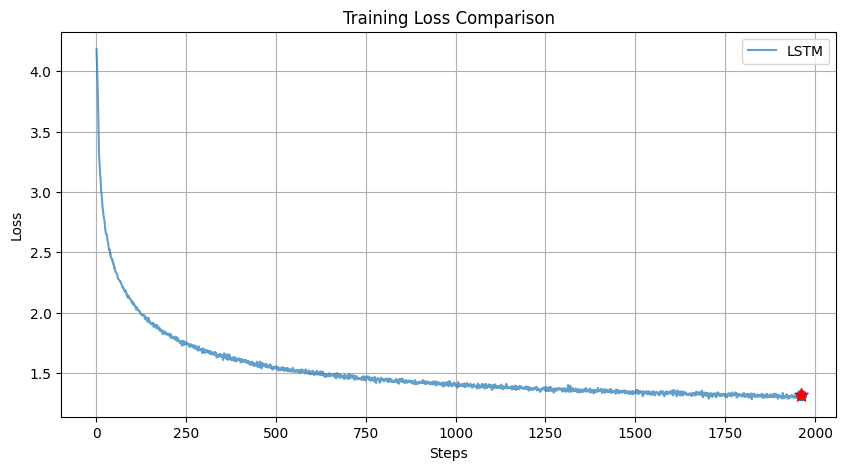

In [42]:
# After you've added multiple models, plot the comparison
plot_loss_comparisons()

## LLama3 Implementation

LLaMA 3 applies different RoPE scaling based on low frequency and high frequency components in the RoPE mechanism, and uses interpolation methods to scale the intermediate frequencies. This approach adds the capability of learning more precise positional information across various frequency bands, especially improving the model's expressiveness in handling long sequences.

In [43]:
def generate_text_attention(model, char_to_idx, idx_to_char, start_text, device, max_length=500):
    model.eval()
    current_text = start_text

    with torch.no_grad():
        for _ in range(max_length):
            # Convert the last sequence of characters to indices and feed it to the model
            x = torch.tensor([[char_to_idx[ch] for ch in current_text[-SEQUENCE_LENGTH:]]]).to(device)
            output = model(x)[0]  # No hidden state needed for attention-based models
            probs = torch.softmax(output[0, -1], dim=0)
            next_char_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_char_idx]
            current_text += next_char

    return current_text

In [46]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math

# RoPE: Rotary Position Embedding function
def apply_rotary_pos_emb(q, k, sin, cos):
    q_rot = (q * cos) + (rotate_half(q) * sin)
    k_rot = (k * cos) + (rotate_half(k) * sin)
    return q_rot, k_rot

def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

# Building the RoPE cache once, to be shared across layers
class RoPECache:
    def __init__(self, seq_len, head_dim, device, base=10000.0, rope_config=None):
        self.sin, self.cos = self.build_rope_cache(seq_len, head_dim, device, base, rope_config)

    @staticmethod
    def default_build_rope_cache(seq_len, head_dim, base, device):
        inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float().to(device) / head_dim))
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        sin, cos = emb.sin(), emb.cos()
        return sin, cos

    @staticmethod
    def build_rope_cache(seq_len, head_dim, device, base, rope_config):
        """
        Builds the RoPE cache (sin and cos values) for rotary position embedding with scaling.

        Args:
            seq_len: Sequence length.
            head_dim: Dimensionality of the attention heads.
            rope_config: Configuration for RoPE scaling (factor, high/low frequency factors, etc.).
            device: Device (CPU/GPU) for computation.

        Returns:
            sin, cos: Sine and cosine values for RoPE scaling.
        """
        if rope_config == None:
            sin, cos = RoPECache.default_build_rope_cache(seq_len, head_dim, device)
            return sin, cos

        ########## 이 부분 작성 ##########

        # Extract RoPE scaling parameters from rope_config
        factor = rope_config['factor']
        low_freq_factor = rope_config['low_freq_factor']
        high_freq_factor = rope_config['high_freq_factor']
        old_context_len = rope_config['original_max_position_embeddings']

        # Compute base inverse frequency
        inv_freq = 1.0 / base ** (torch.arange(0, head_dim, 2).float().to(device) / head_dim)

        # Calculate wavelength for low and high frequency regions
        wavelen = 2 * math.pi / inv_freq

        # Compute wavelength from inverse frequency
        low_freq_wavelen = old_context_len / low_freq_factor
        high_freq_wavelen = old_context_len / high_freq_factor

        # Apply scaling: If wavelength is greater than low_freq_wavelen, scale the frequency
        smooth = (old_context_len / (wavelen - low_freq_factor) / (high_freq_factor - low_freq_factor))
        smooth = torch.clamp(smooth, 0.0, 1.0)

        # For medium frequency, apply smooth interpolation
        scaled_inv_freq = (1 - smooth) * (inv_freq / factor) + smooth * inv_freq

        # Compute the sin and cos values using the scaled inverse frequencies
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.einsum('i,j->ij', t, scaled_inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        sin, cos = emb.sin(), emb.cos()

        return sin, cos

class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super(RMSNorm, self).__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def _norm(self, x):
        # Compute variance and apply reciprocal square root for RMS normalization
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        # Convert to float32 for precision, then back to original dtype
        output = self._norm(x.float()).type_as(x)
        return output * self.weight

# Feed-Forward Network with implicit gating
class FeedForward(nn.Module):
    def __init__(self, d_model, multiple_of, ffn_dim_multiplier=None):
        super(FeedForward, self).__init__()

        hidden_dim = 4 * d_model

        hidden_dim = int(2 * hidden_dim / 3)
        if ffn_dim_multiplier is not None:
            hidden_dim = int(ffn_dim_multiplier * hidden_dim)

        up_hidden_dim = multiple_of * ((hidden_dim + multiple_of - 1) // multiple_of)

        self.gate_proj = nn.Linear(d_model, up_hidden_dim, bias=False)
        self.up_proj = nn.Linear(d_model, up_hidden_dim, bias=False)
        self.down_proj = nn.Linear(up_hidden_dim, d_model, bias=False)
        self.act_fn = F.silu  # SiLU activation

    def forward(self, x):
        gate = self.gate_proj(x)
        up = self.up_proj(x)
        activated = self.act_fn(gate) * up

        output = self.down_proj(activated)
        return output

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, seq_length, num_groups, rope_cache):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.num_kv_heads = num_heads // num_groups  # Calculate num_kv_heads based on num_groups
        self.d_model = d_model
        self.head_dim = d_model // num_heads
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, self.num_kv_heads * self.head_dim, bias=False)
        self.value = nn.Linear(d_model, self.num_kv_heads * self.head_dim, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

        # Use the shared RoPE cache
        self.rope_cache = rope_cache

    def forward(self, x, mask=None):
        batch_size, seq_length, _ = x.size()

        Q = self.query(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_length, self.num_kv_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_length, self.num_kv_heads, self.head_dim).transpose(1, 2)

        sin, cos = self.rope_cache.sin[:seq_length, :].to(x.device), self.rope_cache.cos[:seq_length, :].to(x.device)
        Q_rot, K_rot = apply_rotary_pos_emb(Q, K, sin, cos)

        # Repeat K and V for each query head
        K_rot = K_rot.repeat_interleave(self.num_heads // self.num_kv_heads, dim=1)
        V = V.repeat_interleave(self.num_heads // self.num_kv_heads, dim=1)

        attention_scores = torch.matmul(Q_rot, K_rot.transpose(-2, -1)) / (self.head_dim ** 0.5)
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

        return self.fc_out(attention_output)

class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, multiple_of, num_heads, num_groups, seq_length, ffn_dim_multiplier, rms_norm_eps, rope_cache):
        super(LLaMADecoderLayer, self).__init__()
        self.rmsnorm1 = RMSNorm(embedding_dim, eps=rms_norm_eps)
        self.attention = MultiHeadAttention(embedding_dim, num_heads, seq_length, num_groups, rope_cache)
        self.rmsnorm2 = RMSNorm(embedding_dim, eps=rms_norm_eps)
        self.feed_forward = FeedForward(embedding_dim, multiple_of, ffn_dim_multiplier)

    def forward(self, x, mask):
        normed_x = self.rmsnorm1(x)
        attention_output = self.attention(normed_x, mask)
        x = x + attention_output
        normed_x = self.rmsnorm2(x)
        feed_forward_output = self.feed_forward(normed_x)
        x = x + feed_forward_output
        return x

class LLaMA3Model(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length, num_heads, num_groups, num_layers, multiple_of, ffn_dim_multiplier, rms_norm_eps, rope_theta, rope_scaling):
        super(LLaMA3Model, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Initialize the shared RoPE cache once
        rope_cache = RoPECache(seq_length, embedding_dim // num_heads, torch.device('cpu'), rope_theta, rope_scaling)

        self.layers = nn.ModuleList([
            LLaMADecoderLayer(embedding_dim, multiple_of, num_heads, num_groups, seq_length, ffn_dim_multiplier, rms_norm_eps, rope_cache)
            for _ in range(num_layers)
        ])
        self.rmsnorm_f = RMSNorm(embedding_dim, eps=rms_norm_eps)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        # 1. Embedding Layer
        x = self.embedding(idx)

        seq_length = x.size(1)
        mask = torch.tril(torch.ones(seq_length, seq_length)).to(x.device)

        # 2. Pass through multiple layers (including pre-norm and attention block with RoPE)
        for _, layer in enumerate(self.layers):
            x = layer(x, mask)

        # 3. Final LayerNorm
        x = self.rmsnorm_f(x)

        # 4. Final Output Projection
        logits = self.fc_out(x)

        # Optionally calculate loss if targets are provided
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        else:
            return logits, None

In [47]:
def train_and_test(model_desc, start_text, multiple_of, num_heads, num_layers, num_groups, ffn_dim_multiplier, rms_norm_eps, rope_theta, rope_scaling, device):
    # Initialize the model
    model_llama = LLaMA3Model(vocab_size, EMBEDDING_DIM, SEQUENCE_LENGTH, num_heads, num_groups, num_layers, multiple_of, ffn_dim_multiplier, rms_norm_eps, rope_theta, rope_scaling).to(torch.device(device))

    # Use the same optimizer and criterion
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_llama.parameters(), lr=LEARNING_RATE)

    # Train the model
    trained_model, train_losses_df, val_losses_df = train_model(
        model_llama, train_loader, val_loader, criterion, optimizer, device, EPOCHS
    )

    # Generate text
    generated_text = generate_text_attention(trained_model, char_to_idx, idx_to_char, start_text, device)
    print(f"Generated text [{start_text}]:")
    print("-"*50)
    print(generated_text)

    add_loss_to_comparison(model_desc, train_losses_df, val_losses_df)

    # Plot loss comparisons including this model
    plot_loss_comparisons()

Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 2.5680
Epoch 1, Step 20, Batch 20/1961, Loss: 2.4498
Epoch 1, Step 30, Batch 30/1961, Loss: 2.3317
Epoch 1, Step 40, Batch 40/1961, Loss: 2.2003
Epoch 1, Step 50, Batch 50/1961, Loss: 2.0948
Epoch 1, Step 60, Batch 60/1961, Loss: 1.9715
Epoch 1, Step 70, Batch 70/1961, Loss: 1.8905
Epoch 1, Step 80, Batch 80/1961, Loss: 1.8220
Epoch 1, Step 90, Batch 90/1961, Loss: 1.7236
Epoch 1, Step 100, Batch 100/1961, Loss: 1.6703
Epoch 1, Step 110, Batch 110/1961, Loss: 1.6151
Epoch 1, Step 120, Batch 120/1961, Loss: 1.5732
Epoch 1, Step 130, Batch 130/1961, Loss: 1.5549
Epoch 1, Step 140, Batch 140/1961, Loss: 1.4998
Epoch 1, Step 150, Batch 150/1961, Loss: 1.4875
Epoch 1, Step 160, Batch 160/1961, Loss: 1.4442
Epoch 1, Step 170, Batch 170/1961, Loss: 1.4172
Epoch 1, Step 180, Batch 180/1961, Loss: 1.4254
Epoch 1, Step 190, Batch 190/1961, Loss: 1.4035
Epoch 1, Step 200, Batch 200/1961, Loss: 1.3745
Epoch 1, Step 210, Batch 210/1961, Loss: 1.3867


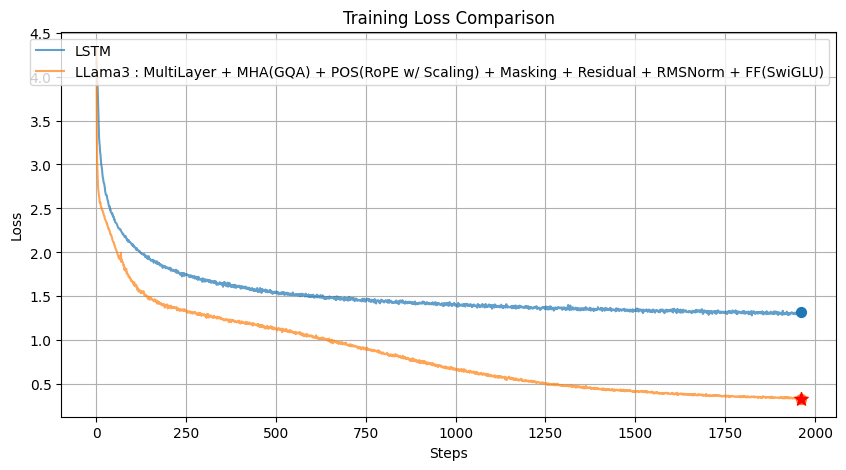

In [48]:
multiple_of = 32
num_heads = 8
num_layers = 6
num_groups = 2

## -- about rope settings, we just followed typical llama3 settings
ffn_dim_multiplier = 1.5 # in case of Llama 3.2 1b -> 1.5
rms_norm_eps = 1e-05
rope_theta = 500000.0
rope_scaling = {
    'factor': 32.0,
    'high_freq_factor': 4.0,
    'low_freq_factor': 1.0,
    'original_max_position_embeddings': 8192,
 }

train_and_test( "LLama3 : MultiLayer + MHA(GQA) + POS(RoPE w/ Scaling) + Masking + Residual + RMSNorm + FF(SwiGLU)",
               start_text, multiple_of, num_heads, num_layers, num_groups, ffn_dim_multiplier, rms_norm_eps, rope_theta, rope_scaling, device)

### Performance Comparison


It shows performance similar to LLaMA2.
The true power of LLaMA3 comes from its longer training on larger datasets and models, as well as its ability to handle significantly larger context windows, allowing it to capture more complex patterns and dependencies over extended sequences.

----

# Comparing Hugging Face's LLaMA with Our Custom Implementation

Finally, we compare our custom LLaMA2 implementation with the Hugging Face LLaMA2 model. This test ensures that our model structure and weight initialization are correct, and that our custom implementation produces the same outputs as the official version.

## Hugging Face LLaMA3 vs Custom LLaMA3

In [ ]:
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load Hugging Face LLaMA 3.x model and tokenizer
model_name = 'unsloth/Llama-3.2-1B'
tokenizer = AutoTokenizer.from_pretrained(model_name)
hf_model = AutoModelForCausalLM.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/884 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

In [ ]:
hf_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm):

In [ ]:
vocab_size = hf_model.config.vocab_size
embedding_dim = hf_model.config.hidden_size
seq_length = hf_model.config.max_position_embeddings
num_heads = hf_model.config.num_attention_heads
num_layers = hf_model.config.num_hidden_layers

num_groups = hf_model.config.num_attention_heads // hf_model.config.num_key_value_heads  # For GQA
multiple_of = 1024
ffn_dim_multiplier = 1.5 # in case of Llama 3.2 1b -> 1.5

rms_norm_eps = hf_model.config.rms_norm_eps
rope_theta = hf_model.config.rope_theta
rope_scaling = hf_model.config.rope_scaling

my_llama = LLaMA3Model(
    vocab_size,
    embedding_dim,
    seq_length,
    num_heads,
    num_groups,
    num_layers,
    multiple_of,
    ffn_dim_multiplier,
    rms_norm_eps,
    rope_theta,
    rope_scaling
    ).to(torch.device('cpu'))

In [ ]:
# Function to copy weights from Hugging Face model to custom model
def copy_all_weights(hf_model, custom_model):
    # Copy embedding weights
    custom_model.embedding.weight.data.copy_(hf_model.model.embed_tokens.weight.data)

    # Copy decoder layer weights
    for i in range(len(custom_model.layers)):
        custom_layer = custom_model.layers[i]
        hf_layer = hf_model.model.layers[i]

        # Copy attention weights (adjusted for GQA)
        custom_layer.attention.query.weight.data.copy_(hf_layer.self_attn.q_proj.weight.data)
        custom_layer.attention.key.weight.data.copy_(hf_layer.self_attn.k_proj.weight.data)
        custom_layer.attention.value.weight.data.copy_(hf_layer.self_attn.v_proj.weight.data)
        custom_layer.attention.fc_out.weight.data.copy_(hf_layer.self_attn.o_proj.weight.data)

        # Copy LayerNorm weights (Pre and Post attention)
        custom_layer.rmsnorm1.weight.data.copy_(hf_layer.input_layernorm.weight.data)
        custom_layer.rmsnorm2.weight.data.copy_(hf_layer.post_attention_layernorm.weight.data)

        # Copy Feed-Forward weights
        custom_layer.feed_forward.gate_proj.weight.data.copy_(hf_layer.mlp.gate_proj.weight.data)
        custom_layer.feed_forward.up_proj.weight.data.copy_(hf_layer.mlp.up_proj.weight.data)
        custom_layer.feed_forward.down_proj.weight.data.copy_(hf_layer.mlp.down_proj.weight.data)

    # Copy final LayerNorm and output projection weights
    custom_model.rmsnorm_f.weight.data.copy_(hf_model.model.norm.weight.data)
    custom_model.fc_out.weight.data.copy_(hf_model.lm_head.weight.data)

    print("All weights copied successfully.")

# Hugging Face model's logits
def get_hf_logits(hf_model, input_ids):
    with torch.no_grad():
        hf_logits = hf_model(input_ids).logits
    return hf_logits

# Custom model's logits
def get_custom_logits(custom_model, input_ids):
    logits, _ = custom_model(input_ids)
    return logits

# Compare the logits
def compare_logits(hf_logits, custom_logits, atol=1e-5):
    print("\nHugging Face Logits (Subset):", hf_logits[0, :5])
    print("\nCustom Model Logits (Subset):", custom_logits[0, :5])

    if torch.allclose(hf_logits, custom_logits, atol=atol):
        print("Logits match within tolerance", atol, "!")
    else:
        print("Logits do not match!")
        diff = (hf_logits - custom_logits).abs()
        max_diff = diff.max()
        print("Max difference:", max_diff)

        mismatched_positions = (diff > atol).nonzero(as_tuple=True)
        print("Mismatched positions:", mismatched_positions)
        print("Hugging Face Logits at mismatch:", hf_logits[mismatched_positions])
        print("Custom Model Logits at mismatch:", custom_logits[mismatched_positions])

# Main function to copy, extract, and compare final logits
def test_logits_comparison(hf_model, custom_model, text, tokenizer):
    # Tokenize input text
    input_ids = tokenizer(text, return_tensors="pt")["input_ids"]

    # Step 1: Copy all weights from Hugging Face to custom model
    copy_all_weights(hf_model, custom_model)

    # Step 2: Get logits from both models
    hf_logits = get_hf_logits(hf_model, input_ids)
    custom_logits = get_custom_logits(custom_model, input_ids)

    # Step 3: Compare the logits
    compare_logits(hf_logits, custom_logits)

# Example usage:
# Assume hf_model is already loaded as Hugging Face model and tokenizer is loaded
test_logits_comparison(hf_model, my_llama, "This is a test sentence.", tokenizer)

### Comparison in a High-Precision Environment (64-bit Floating Point)

In 32-bit or 16-bit environments, small numerical errors accumulate during operations like normalization, scaling, or activation functions due to rounding. Even if two architectures are identical, these small differences can lead to slightly different outputs. As we saw earlier in the 32-bit environment, the results from the two models were extremely close, but there were still minor differences due to these accumulated errors.

To conclusively demonstrate that the two architectures are truly the same, we move to a 64-bit floating-point environment. In 64-bit precision, very small values are calculated and preserved with much higher accuracy, eliminating the numerical errors caused by rounding in lower precision environments.

In [ ]:
import copy
import torch

# Function to copy weights from Hugging Face model to custom model for double precision comparison
def copy_all_weights_64(hf_model, custom_model):
    # Copy embedding weights
    custom_model.embedding.weight.data.copy_(hf_model.model.embed_tokens.weight.data)

    # Iterate over all decoder layers
    for i in range(len(custom_model.layers)):
        custom_layer = custom_model.layers[i]
        hf_layer = hf_model.model.layers[i]

        # Copy attention weights (q_proj, k_proj, v_proj, o_proj)
        custom_layer.attention.query.weight.data.copy_(hf_layer.self_attn.q_proj.weight.data)
        custom_layer.attention.key.weight.data.copy_(hf_layer.self_attn.k_proj.weight.data)
        custom_layer.attention.value.weight.data.copy_(hf_layer.self_attn.v_proj.weight.data)
        custom_layer.attention.fc_out.weight.data.copy_(hf_layer.self_attn.o_proj.weight.data)

        # Copy LayerNorm weights
        custom_layer.rmsnorm1.weight.data.copy_(hf_layer.input_layernorm.weight.data)
        custom_layer.rmsnorm2.weight.data.copy_(hf_layer.post_attention_layernorm.weight.data)

        # Copy Feed-Forward weights
        custom_layer.feed_forward.gate_proj.weight.data.copy_(hf_layer.mlp.gate_proj.weight.data)
        custom_layer.feed_forward.up_proj.weight.data.copy_(hf_layer.mlp.up_proj.weight.data)
        custom_layer.feed_forward.down_proj.weight.data.copy_(hf_layer.mlp.down_proj.weight.data)

    # Copy final LayerNorm and output projection weights
    custom_model.rmsnorm_f.weight.data.copy_(hf_model.model.norm.weight.data)
    custom_model.fc_out.weight.data.copy_(hf_model.lm_head.weight.data)

    print("All weights copied successfully in double precision.")

# Function to get logits from Hugging Face model in double precision
def get_hf_logits_64(hf_model, input_ids):
    # Run forward pass for Hugging Face model and get the logits in double precision
    with torch.no_grad():
        hf_logits = hf_model(input_ids).logits.double()
    return hf_logits

# Function to get logits from custom model in double precision
def get_custom_logits_64(custom_model, input_ids):
    # Run the custom model to get the logits in double precision
    logits, _ = custom_model(input_ids)
    return logits.double()

# Compare the logits in 64-bit precision
def compare_logits_64(hf_logits, custom_logits, atol=1e-8):
    print("\nHugging Face Logits (Subset):", hf_logits[0, :5])
    print("\nCustom Model Logits (Subset):", custom_logits[0, :5])

    if torch.allclose(hf_logits, custom_logits, atol=atol):
        print("Logits match within tolerance", atol, "!")
    else:
        print("Logits do not match!")
        diff = (hf_logits - custom_logits).abs()
        max_diff = diff.max()
        print("Max difference:", max_diff)

        # Print detailed differences where the mismatch occurs
        mismatched_positions = (diff > atol).nonzero(as_tuple=True)
        print("Mismatched positions:", mismatched_positions)
        print("Hugging Face Logits at mismatch:", hf_logits[mismatched_positions])
        print("Custom Model Logits at mismatch:", custom_logits[mismatched_positions])

# Main function to run comparison in 64-bit precision
def test_logits_comparison_64(hf_model_64, custom_model_64, text, tokenizer):
    # Tokenize input text and convert input_ids to 64-bit integers
    input_ids = tokenizer(text, return_tensors="pt")["input_ids"].to(torch.int64)

    # Step 1: Copy all weights from Hugging Face to custom model (in double precision)
    copy_all_weights_64(hf_model_64, custom_model_64)

    # Step 2: Get logits from both models in 64-bit precision
    hf_logits = get_hf_logits_64(hf_model_64, input_ids)
    custom_logits = get_custom_logits_64(custom_model_64, input_ids)

    # Step 3: Compare the logits in double precision
    compare_logits_64(hf_logits, custom_logits)

# Example usage:
hf_model_64 = copy.deepcopy(hf_model).double()  # Convert Hugging Face model to 64-bit precision
my_llama_64 = copy.deepcopy(my_llama).double()  # Convert custom model to 64-bit precision

# Run comparison test in 64-bit precision
test_logits_comparison_64(hf_model_64, my_llama_64, "This is a test sentence.", tokenizer)


# Conclusion

The notebook presents a comprehensive guide for implementing the LLaMA 3 model from scratch. We started by configuring key parameters such as multiple_of, num_heads, num_layers, and ffn_dim_multiplier. This walkthrough covered each essential step, providing a detailed understanding of LLaMA 3's architecture and functionality.

A notable difference between LLaMA 3 and LLaMA 2 is in the implementation of the RoPE (Rotary Position Embedding). LLaMA 3 introduces frequency-based scaling, where low and high frequencies are scaled differently, while intermediate frequencies use an interpolation method. This enhancement allows the model to learn more precise positional information, especially improving its expressiveness when handling long sequences.

We also included comparisons between the custom model and the Hugging Face model, using different parameter settings to ensure consistency and validate our implementation's performance.